# Data Cleaning & EDA & Attributes Selection Analysis

In [1]:
import pandas as pd
import numpy as np
import ast
import os
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')

print("Imports OK")


Imports OK


In [2]:
business = pd.read_parquet("data/business_y_removed.parquet")
print(f"business : {business.shape}")

review   = pd.read_parquet("data/review.parquet", columns=['business_id', 'stars', "text"])
print(f"review   : {review.shape}")

tip      = pd.read_parquet("data/tip.parquet")
print(f"tip      : {tip.shape}")

business : (150346, 14)
review   : (6990280, 3)
tip      : (908915, 5)


In [3]:
# check columns in business
print(f"\nbusiness columns: {business.columns.tolist()}")


business columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']


# 1. Data Cleaning

## 1.1 Restaurant Filter 

**Method filtering Restaurant we use:**: 
- keep any business whose `categories` **or** `attributes`
contain the word "restaurant/restaurants" (case-insensitive word-boundary regex).

In [4]:
# create filtering function to check whether there is restaurant word or not 
def has_restaurant_attribute(attr):
    if pd.isna(attr) or attr is None:
        return False
    if isinstance(attr, str):
        try:
            attr = ast.literal_eval(attr)
        except Exception:
            return False
    if not isinstance(attr, dict):
        return False
    return any("restaurant" in k.lower() for k in attr.keys())

# assigning regex 
pattern   = r"\\brestaurants?\\b"

# check regex in both categories and attributes
cat_check  = business['categories'].str.contains(pattern, case=False, na=False, regex=True)
attr_check = business['attributes'].apply(has_restaurant_attribute)

# apply both condition and assign to new variable
restaurant_cond       = cat_check | attr_check
restaurant_businesses = business[restaurant_cond].copy()

print(f"Total businesses           : {business.shape[0]:,}")
print(f"Matched via categories     : {cat_check.sum():,}")
print(f"Matched via attributes     : {attr_check.sum():,}")
print(f"Total restaurants (either) : {len(restaurant_businesses):,}")


Total businesses           : 150,346
Matched via categories     : 0
Matched via attributes     : 136,602
Total restaurants (either) : 136,602


## 1.2 Atributes Extraction

**Method to extract attributes from the dictionary (AI Citation: Claude)**
1. `safe_parse_attributes` — converts raw column value (string or dict) → Python `dict`.
2. `flatten_attributes` — expands nested dicts (Ambience, GoodForMeal, BusinessParking …),
   normalises all boolean-string variants, converts Alcohol categoricals → `True/False`.
3. `to_binary` — maps a single flattened value to `1 / 0 / NaN`.


In [5]:
def safe_parse_attributes(attr_val):
    if attr_val is None or (isinstance(attr_val, float) and pd.isna(attr_val)):
        return {}
    if isinstance(attr_val, dict):
        return attr_val
    try:
        parsed = ast.literal_eval(str(attr_val))
        return parsed if isinstance(parsed, dict) else {}
    except (ValueError, SyntaxError):
        return {}


def flatten_attributes(attrs_dict):
    flat = {}
    for key, val in attrs_dict.items():
        if val is None or str(val).lower() in ('none', 'nan'):
            continue

        # ── nested dict (Ambience, GoodForMeal, BusinessParking, …) ──
        if isinstance(val, str) and val.startswith('{'):
            try:
                nested = ast.literal_eval(val)
                if isinstance(nested, dict):
                    for nk, nv in nested.items():
                        flat[f"{key}_{nk}"] = nv
                    continue
            except (ValueError, SyntaxError):
                pass

        if isinstance(val, str):
            # Strip whitespace + every combination of outer quotes/u-prefix
            vl = val.strip().lower().strip("'\"").lstrip('u').strip("'\"")
            if vl == 'true':
                flat[key] = True
            elif vl in ('false', 'none', 'no'):
                flat[key] = False
            elif vl in ('full_bar', 'beer_and_wine'):   # Alcohol has value → alcohol present
                flat[key] = True
            else:
                flat[key] = vl   # keep other categoricals as lowercase string
        elif isinstance(val, bool):
            flat[key] = val
        else:
            flat[key] = val
    return flat


def to_binary(flat_dict, key):
    """
    Convert a single flattened attribute value to 1 / 0 / NaN.
    NaN means the restaurant did not specify this attribute at all.
    """
    val = flat_dict.get(key, None)
    if val is None:
        return np.nan
    if isinstance(val, bool):
        return int(val)
    if isinstance(val, str):
        if val.lower() in ('true', '1'):   return 1
        if val.lower() in ('false', '0', 'none', 'no'): return 0
    return np.nan   # remaining categoricals → skip


print("Attribute parsing functions defined.")


Attribute parsing functions defined.


In [6]:
# Parse attributes for ALL restaurants (BEFORE lowercasing the text fields!)

# apply created column on 'attrs_parsed' and 'attrs_flat' on both created functions
restaurant_businesses['attrs_parsed'] = (restaurant_businesses['attributes'].apply(safe_parse_attributes))
restaurant_businesses['attrs_flat'] = (restaurant_businesses['attrs_parsed'].apply(flatten_attributes))
print(f"Parsed attributes for {len(restaurant_businesses):,} restaurants.")


Parsed attributes for 136,602 restaurants.


## 1.3 Cleaning and Standardization of Features

We create some new features by extracting from exisitng 'hours' columns.

**Method used:**
- `days_open` — count of days with non-None hours, zeros imputed from postal-code median (our assumption to tackle NA values)
- `avg_daily_hours` — average opening duration per day, zeros imputed similarly
- Remove duplicate `business_id` rows

In [7]:
def count_days_open(hours): # our original code
    if pd.isna(hours) or hours is None:
        return 0
    if isinstance(hours, dict):
        return sum(1 for v in hours.values() if v is not None)
    try:
        parsed = ast.literal_eval(str(hours))
        return sum(1 for v in parsed.values() if v is not None)
    except Exception:
        return 0


def avg_daily_hours_fn(hours): # claude code for avg_daily_hours part (AI: Citation)
    if pd.isna(hours) or hours is None:
        return 0
    if isinstance(hours, str):
        try:
            hours = ast.literal_eval(hours)
        except Exception:
            return 0
    if not isinstance(hours, dict):
        return 0
    daily = []
    for _, time_range in hours.items():
        try:
            open_t, close_t = time_range.split('-')
            oh, om = map(int, open_t.split(':'))
            ch, cm = map(int, close_t.split(':'))
            open_m  = oh * 60 + om
            close_m = ch * 60 + cm
            if close_m < open_m:
                close_m += 24 * 60
            daily.append((close_m - open_m) / 60)
        except Exception:
            continue
    return round(sum(daily) / len(daily), 2) if daily else 0


# assign as new column in the datasets
restaurant_businesses['days_open']      = restaurant_businesses['hours'].apply(count_days_open)
restaurant_businesses['avg_daily_hours'] = restaurant_businesses['hours'].apply(avg_daily_hours_fn)

# Apply data imputation zeros via postal-code median 
for col in ['days_open', 'avg_daily_hours']:
    global_med = restaurant_businesses.loc[restaurant_businesses[col] > 0, col].median()
    postal_med = (restaurant_businesses[restaurant_businesses[col] > 0].groupby('postal_code')[col].median())
    mask    = restaurant_businesses[col] == 0
    imputed = restaurant_businesses.loc[mask, 'postal_code'].map(postal_med).fillna(global_med)
    restaurant_businesses.loc[mask, col] = imputed
    if col == 'days_open':
        restaurant_businesses[col] = restaurant_businesses[col].round().astype(int)


In [8]:
# remove duplicates
before = len(restaurant_businesses)
restaurant_businesses.drop_duplicates(subset='business_id', inplace=True)

print(f"Restaurants after cleaning : {len(restaurant_businesses):,}  "
      f"(removed {before - len(restaurant_businesses)} dupes)")
print(f"Remaining zeros — days_open      : {(restaurant_businesses['days_open'] == 0).sum()}")
print(f"Remaining zeros — avg_daily_hours: {(restaurant_businesses['avg_daily_hours'] == 0).sum()}")

Restaurants after cleaning : 136,602  (removed 0 dupes)
Remaining zeros — days_open      : 0
Remaining zeros — avg_daily_hours: 0


## 1.4 Data Splitting

In [9]:
# SPLIT LABELED / UNLABELED 
rest_labeled   = restaurant_businesses.dropna(subset=['is_open']).copy()
rest_labeled['is_open'] = rest_labeled['is_open'].astype(int)
rest_unlabeled = restaurant_businesses[restaurant_businesses['is_open'].isna()].copy()

print(f"Labeled   : {len(rest_labeled):,}  "
      f"(Open: {(rest_labeled['is_open']==1).sum():,}  |  "
      f"Closed: {(rest_labeled['is_open']==0).sum():,})")
print(f"  Open rate : {rest_labeled['is_open'].mean():.1%}")
print(f"Unlabeled : {len(rest_unlabeled):,}  (prediction set)")


Labeled   : 109,280  (Open: 85,980  |  Closed: 23,300)
  Open rate : 78.7%
Unlabeled : 27,322  (prediction set)


## 2. Attribute Matrix

So, since the attribute is categorical, we can apply method like "one-hot encoded"
Ex:ample to better understand:
| Restaurant | Delivery | HasTV | DriveThru | ClassyAmbience |
| ---------- | -------- | ----- | --------- | -------------- |
| R1         | 1        | 0     | 0         | 1              |
| R2         | 0        | 1     | 0         | 0              |
| R3         | 1        | 1     | 1         | 0              |


In [10]:
# Firstly, we collect all unique attribute keys across ALL restaurants with the column we created previously to get each attributes
all_flat_keys = set()
for d in restaurant_businesses['attrs_flat']:
    all_flat_keys.update(d.keys())
print(f"Total unique attribute keys (all restaurants): {len(all_flat_keys)}")

Total unique attribute keys (all restaurants): 81


So, we have 81 unique attributes accross all restaurats iin the datasets

In [11]:
# convert the aatributes extracted to binary matrix for ALL restaurants (AI: Citation)
attr_df_all = pd.DataFrame({key: restaurant_businesses['attrs_flat']
                            .apply(lambda d, k=key: to_binary(d, k)) for key in sorted(all_flat_keys)},
                           index=restaurant_businesses.index)

# We evaluate prevalence on labeled restaurants only, so that attributes common
attr_df_labeled = attr_df_all.loc[rest_labeled.index]

In [12]:
# For each attribute column, wecompute the fraction of labeled restaurants
prevalence = (attr_df_labeled == 1).mean()

# Keep only attributes present in at least 5% of labeled restaurants.
kept_cols = prevalence[prevalence >= 0.05].index.tolist()

# Rare attributes (<5%) are dropped because:
dropped_cols = prevalence[prevalence < 0.05].index.tolist()


print(f"Binary attribute columns      : {len(attr_df_all.columns)}")
print(f"Kept (≥5%% prevalence)         : {len(kept_cols)}")
print(f"Dropped (<5%% prevalence)      : {len(dropped_cols)}")
print(f"\nKept attributes:")
for c in kept_cols:
    pct = (attr_df_labeled[c] == 1).mean() * 100
    print(f"  {c:<42s}  {pct:5.1f}%%")

Binary attribute columns      : 81
Kept (≥5%% prevalence)         : 21
Dropped (<5%% prevalence)      : 60

Kept attributes:
  Alcohol                                      16.3%%
  Ambience_casual                              15.3%%
  BikeParking                                  40.3%%
  BusinessAcceptsCreditCards                   83.2%%
  BusinessParking_lot                          32.4%%
  BusinessParking_street                       16.9%%
  ByAppointmentOnly                            11.4%%
  Caters                                       16.4%%
  GoodForKids                                  32.2%%
  GoodForMeal_dinner                            9.6%%
  GoodForMeal_lunch                            10.4%%
  HappyHour                                     7.1%%
  HasTV                                        25.1%%
  OutdoorSeating                               16.5%%
  RestaurantsDelivery                          23.6%%
  RestaurantsGoodForGroups                     27.9%%
  Restauran

From the initial 81 binary attribute features extracted from the dataset, attributes that appeared in fewer than 5% of labeled restaurants were removed to reduce noise and sparsity. This resulted in a final set of 21 attributes used for predictive modeling.

## 3. Part 1a — Attribute Selection Analysis

**How we define success?**

Using only `is_open` produces misleading results: fast-food chains (McDonald's, Burger King)
almost never close, so `DriveThru` becomes the top recommendation.

A composite success metric filters those out and focuses on genuinely high-quality,
well-established restaurants:

| Condition | Meaning |
|-----------|---------|
| `stars >= 4.0` | High quality rating |
| `review_count >= 20` | Enough reviews to be statistically meaningful |
| `is_open == 1` | Still operating |


In [13]:
rest_labeled['success'] = ( (rest_labeled['stars']        >= 4.0) &
    (rest_labeled['review_count'] >= 20)  &
    (rest_labeled['is_open']      == 1) ).astype(int)

baseline = rest_labeled['success'].mean()
n_success = rest_labeled['success'].sum()

print(f"Successful restaurants : {n_success:,} / {len(rest_labeled):,}")
print(f"Baseline success rate  : {baseline:.1%}")


Successful restaurants : 20,030 / 109,280
Baseline success rate  : 18.3%


## 3.1 PP Difference + Chi-Square Test

For each attribute:
- **PP Difference** = success_rate(has attribute) − success_rate(no attribute)
- **Chi-square Independence test** = is this difference statistically real or random chance?

We keep only attributes where `p < 0.05` (significant) **and** PP Difference > 0 (helps success).


In [14]:
# Store results of attribute screening
screening_results = []

y_success= rest_labeled['success']
 
# Attribute dataframe that passed the 5% prevalence filter earlier
attr_df_lab_kept = attr_df_labeled[kept_cols]

# loop through each attribute column to evaluate its relationship with success
for col in kept_cols:
    # Extract the attribute column
    col_data = attr_df_lab_kept[col]
    combined = pd.DataFrame({'attr': col_data, 'success': y_success}).dropna(subset=['attr'])

    # Split dataset into two groups
    has   = combined[combined['attr'] == 1]
    hasnt = combined[combined['attr'] == 0]

    # then we skip attributes where either group is too small to prevents unstable statistics
    if len(has) < 30 or len(hasnt) < 30:
        continue

    # calculate success
    success_with    = has['success'].mean()
    success_without = hasnt['success'].mean()
    pp_diff         = success_with - success_without

    # contingency table for Chi-Square test, and this part is from (ChatGPT)(AI: Citation)
    # Rows = attribute (0 or 1) Columns = success outcome (0 or 1) 
    ct = pd.crosstab(combined['attr'], combined['success'])
    if ct.shape == (2, 2):
        chi2_stat, p, _, _ = chi2_contingency(ct)
        screening_results.append({
            'attribute':            col,
            'n_with':               len(has),
            'n_without':            len(hasnt),
            'prevalence':           len(has) / len(combined),
            'success_rate_with':    success_with,
            'success_rate_without': success_without,
            'pp_difference':        pp_diff,
            'chi2':                 chi2_stat,
            'p_value':              p,
            'significant':          p < 0.05,
        })

In [15]:
screen_df = (pd.DataFrame(screening_results).sort_values('pp_difference', ascending=False).reset_index(drop=True))

print("=== All attributes ranked by PP Difference ===")
print(screen_df[['attribute', 'pp_difference', 'success_rate_with','success_rate_without', 'chi2', 'p_value', 'significant']].to_string(index=False, float_format='%.4f'))

=== All attributes ranked by PP Difference ===
                 attribute  pp_difference  success_rate_with  success_rate_without      chi2  p_value  significant
           Ambience_casual         0.1954             0.3566                0.1611 1650.3441   0.0000         True
    BusinessParking_street         0.1788             0.3515                0.1726 2503.1194   0.0000         True
         GoodForMeal_lunch         0.1753             0.3991                0.2237  742.9772   0.0000         True
        GoodForMeal_dinner         0.1708             0.4185                0.2477  723.3618   0.0000         True
            OutdoorSeating         0.1156             0.3057                0.1902  675.3257   0.0000         True
               BikeParking         0.0853             0.2711                0.1858  411.2059   0.0000         True
        RestaurantsTakeOut         0.0806             0.2489                0.1682  124.1221   0.0000         True
   RestaurantsTableService       

**Findings Based on PP Difference & Chi Square Screening:** After applying the PP Difference and Chi-Square screening method, all candidate attributes were ranked according to their percentage point (PP) difference, which measures the difference in success rates between restaurants with and without each attribute.

## 3.2 PP Difference plotting

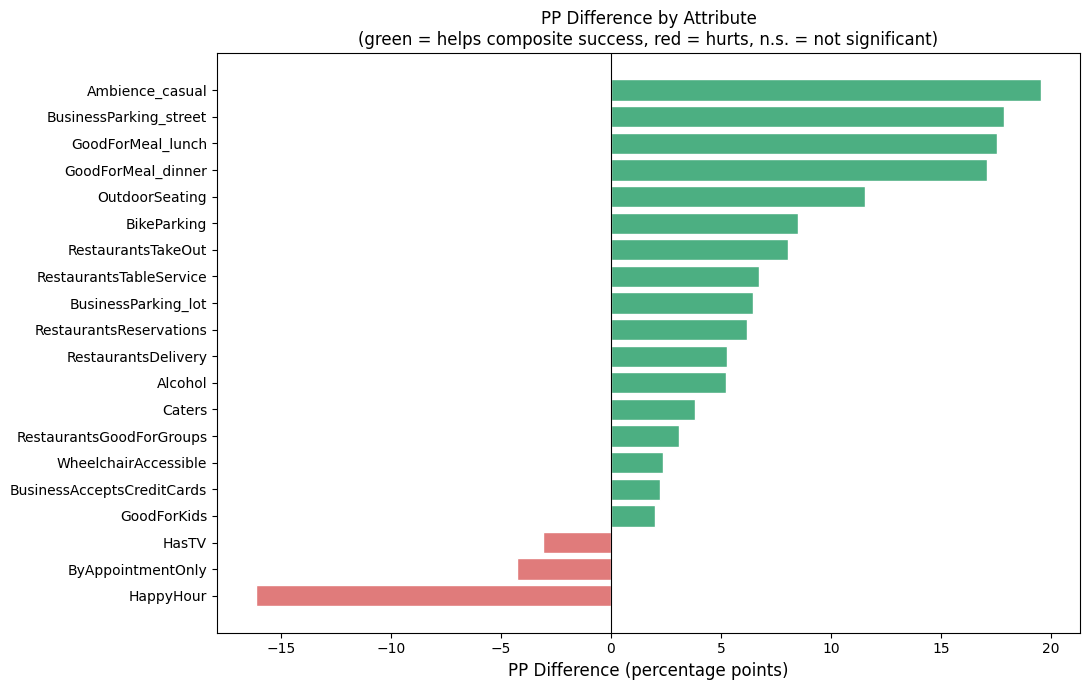

In [18]:
#
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#4caf82' if x > 0 else '#e07b7b' for x in screen_df['pp_difference']]
ax.barh(screen_df['attribute'], screen_df['pp_difference'] * 100, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for i, row in screen_df.iterrows():
    if not row['significant']:
        x = row['pp_difference'] * 100
        ax.text(x + (0.3 if x >= 0 else -0.3), i, 'n.s.', va='center', fontsize=7, color='gray')
ax.set_xlabel('PP Difference (percentage points)', fontsize=12)
ax.set_title(
    'PP Difference by Attribute\n(green = helps composite success, red = hurts, n.s. = not significant)',
    fontsize=12
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


The PP Difference analysis shows how different restaurant attributes are associated with business success. 
- positive PP differences (green) - linked to higher success rates
- negative PP differences (red) - attributes associated with lower success rates.

**Findings:**
Several attributes demonstrate strong positive relationships with success. In particular, casual ambience, street parking availability, and offering lunch or dinner meals show the largest positive effects, each increasing success probability by roughly 17–20 percentage points. Other service-related attributes such as outdoor seating, bike parking, takeout, and table service also show meaningful positive associations with restaurant success.

## 4 Composite Ranking & Final Top 5
After identifying statistically significant attributes using PP Difference and the Chi-Square test, we combine both metrics into a single composite score to rank the attributes.

Combine both chi-square metrics into one score:
- **Rank_PP** — based on the PP Difference (higher = better impact on success)
- **Rank_Chi2** — based on the Chi-Square statistic (higher = stronger statistical association)

The composite score is calculated as the average of the two ranks.

Lower composite scores indicate attributes that are both:
- strongly associated with success
- statistically robust

Only attributes satisfying the following conditions are considered:
- p-value < 0.05 (statistically significant)
- PP Difference > 0 (improves success probability)

## 4.1 Method Application

In [19]:
candidates = screen_df[(screen_df['significant']) & (screen_df['pp_difference'] > 0)].copy()

# rank by PP difference and chi-square statistic from chi-square test previously
candidates['rank_pp'] = candidates['pp_difference'].rank(ascending=False)
candidates['rank_chi2'] = candidates['chi2'].rank(ascending=False)
candidates['composite_score'] = candidates[['rank_pp', 'rank_chi2']].mean(axis=1)

# Combine both rankings into a composite score which shows lower composite score means better overall ranking
candidates = candidates.sort_values('composite_score').reset_index(drop=True)

# display method by formatting first then display all
disp = candidates.copy()
disp['PP Diff (pp)'] = (disp['pp_difference'] * 100).round(1)
disp['Success Rate (with) %'] = (disp['success_rate_with'] * 100).round(1)
disp['Chi2 Stat'] = disp['chi2'].round(1)
disp['p-value'] = disp['p_value'].apply(lambda x: f"{x:.2e}")
disp['Composite Score'] = disp['composite_score'].round(1)

print("=== COMBINED RESULTS: Chi-Square Analysis ===")
print(disp[['attribute', 'PP Diff (pp)', 'Success Rate (with) %',
             'Chi2 Stat', 'p-value', 'Composite Score']]
      .to_string(index=False))


=== COMBINED RESULTS: Chi-Square Analysis ===
                 attribute  PP Diff (pp)  Success Rate (with) %  Chi2 Stat   p-value  Composite Score
           Ambience_casual          19.5                   35.7     1650.3  0.00e+00              1.5
    BusinessParking_street          17.9                   35.1     2503.1  0.00e+00              1.5
         GoodForMeal_lunch          17.5                   39.9      743.0 1.35e-163              3.0
        GoodForMeal_dinner          17.1                   41.9      723.4 2.49e-159              4.0
            OutdoorSeating          11.6                   30.6      675.3 6.94e-149              5.0
               BikeParking           8.5                   27.1      411.2  2.00e-91              6.5
       BusinessParking_lot           6.4                   25.4      414.3  4.22e-92              7.5
        RestaurantsTakeOut           8.1                   24.9      124.1  7.92e-29              8.5
   RestaurantsReservations          

Selecting the Final Top 5 Attribute Groups

Some attributes belong to the same conceptual group.

For example:
| Attribute              | Group           |
| ---------------------- | --------------- |
| Ambience_casual        | Ambience        |
| GoodForMeal_lunch      | GoodForMeal     |
| BusinessParking_street | BusinessParkin
To avoid selecting multiple attributes from the same category, we deduplicate by attribute group.

The final Top 5 list therefore represents five distinct feature groups rather than five sub-attributes.g |


In [46]:
# convert to csv
export_combined = disp[[
    'attribute',
    'PP Diff (pp)',
    'Success Rate (with) %',
    'Chi2 Stat',
    'p-value',
    'Composite Score'
]]
export_combined.to_csv("combined_attribute_ranking.csv", index=False)

print("CSV exported: combined_attribute_ranking.csv")

CSV exported: combined_attribute_ranking.csv


In [32]:
# FINAL TOP 5 (one per attribute group) 

# Function to group related attributes
def get_group(attr):
    if attr.startswith('Ambience'): 
        return 'Ambience'
    if attr.startswith('GoodForMeal'):
        return 'GoodForMeal'
    if attr.startswith('BusinessParking'):
        return 'BusinessParking'
    return attr

top5 = []
used_groups = set()

# Iterate through ranked candidates
for _, row in candidates.iterrows():
    grp = get_group(row['attribute'])
    if grp in used_groups:
        continue
    top5.append(row)
    used_groups.add(grp)
    if len(top5) == 5:
        break
# Convert results into DataFrame
top5_df = pd.DataFrame(top5).reset_index(drop=True)

In [31]:
# print and display result
print("=" * 70)
print("FINAL TOP 5 ATTRIBUTE RECOMMENDATIONS")
print("=" * 70)
print(f"Baseline success rate: {baseline:.1%}\n")
for i, row in top5_df.iterrows():
    print(f"{i+1}. {row['attribute']}")
    print(f"   Success rate with it: {row['success_rate_with']*100:.1f}%  "
          f"(baseline {baseline*100:.1f}%,  +{row['pp_difference']*100:.1f} pp)")
    print(f"   Chi-square: chi2={row['chi2']:.1f},  p={row['p_value']:.2e}")
    print()

FINAL TOP 5 ATTRIBUTE RECOMMENDATIONS
Baseline success rate: 18.3%

1. Ambience_casual
   Success rate with it: 35.7%  (baseline 18.3%,  +19.5 pp)
   Chi-square: chi2=1650.3,  p=0.00e+00

2. BusinessParking_street
   Success rate with it: 35.1%  (baseline 18.3%,  +17.9 pp)
   Chi-square: chi2=2503.1,  p=0.00e+00

3. GoodForMeal_lunch
   Success rate with it: 39.9%  (baseline 18.3%,  +17.5 pp)
   Chi-square: chi2=743.0,  p=1.35e-163

4. OutdoorSeating
   Success rate with it: 30.6%  (baseline 18.3%,  +11.6 pp)
   Chi-square: chi2=675.3,  p=6.94e-149

5. BikeParking
   Success rate with it: 27.1%  (baseline 18.3%,  +8.5 pp)
   Chi-square: chi2=411.2,  p=2.00e-91



## 4.2 Visualization of Top 5 Attributes

To illustrate the practical impact of the selected attributes, we compare the success rate of restaurants with the attribute versus those without it.

The dashed horizontal line represents the baseline success rate across all restaurants.

This visualization highlights how each attribute improves success probability relative to the baseline.

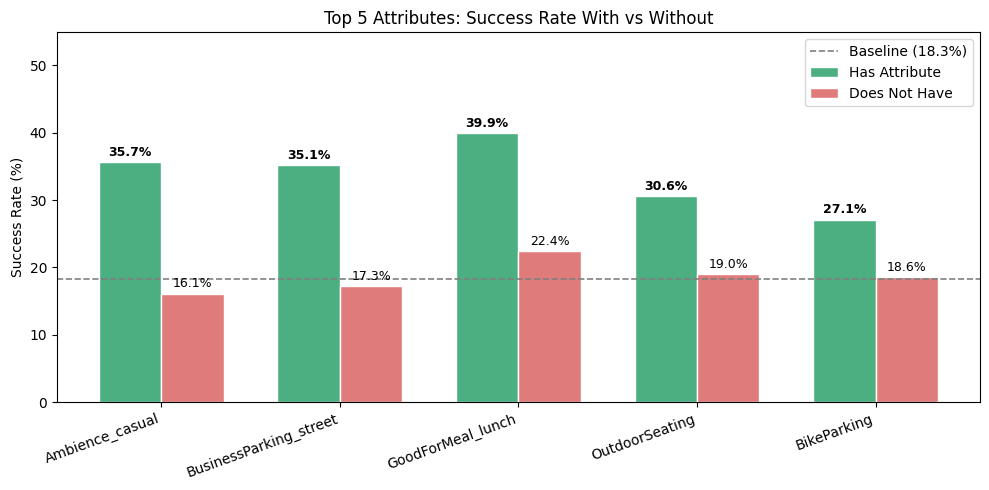

In [30]:
# TOP 5 SIDE-BY-SIDE CHART 

# Ensure the dataframe contains success_rate_without
if 'success_rate_without' not in top5_df.columns:
    top5_df = top5_df.merge(screen_df[['attribute', 'success_rate_without']], on='attribute', how='left')
    top5_df['success_rate_without'] = top5_df['success_rate_without'].fillna(baseline)

# Create bar chart (AI Citation ChatGPT)
fig, ax = plt.subplots(figsize=(10, 5))
x, width = np.arange(len(top5_df)), 0.35

bars_with    = ax.bar(x - width/2, top5_df['success_rate_with']    * 100, width,
                      label='Has Attribute', color='#4caf82', edgecolor='white')
bars_without = ax.bar(x + width/2, top5_df['success_rate_without'] * 100, width,
                      label='Does Not Have', color='#e07b7b', edgecolor='white')

for bar in bars_with:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars_without:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(baseline * 100, color='gray', linestyle='--', linewidth=1.2,
           label=f'Baseline ({baseline:.1%})')
ax.set_xticks(x)
ax.set_xticklabels(top5_df['attribute'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Success Rate (%)')
ax.set_ylim(0, top5_df['success_rate_with'].max() * 100 + 15)
ax.set_title('Top 5 Attributes: Success Rate With vs Without', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 5 Feature Engineering

### 5.1 `top10_attr_count` new column

For each restaurant — labeled **and** unlabeled — count how many of the
**top 10 chi-square-composite-ranked attributes** it has.

Result is an integer from 0 to 10 that summarises, in a single column,
"how aligned is this restaurant with the profile of successful restaurants".


In [35]:
# Top 10 by composite score
top10_attrs = candidates['attribute'].head(10).tolist()

print("Top 10 attributes by composite score:")
for i, a in enumerate(top10_attrs, 1):

    row = candidates[candidates['attribute'] == a].iloc[0]

    print(
        f"{i:2d}. {a:<42s} "
        f"PP={row['pp_difference']*100:+.1f}pp"
    )

Top 10 attributes by composite score:
 1. Ambience_casual                            PP=+19.5pp
 2. BusinessParking_street                     PP=+17.9pp
 3. GoodForMeal_lunch                          PP=+17.5pp
 4. GoodForMeal_dinner                         PP=+17.1pp
 5. OutdoorSeating                             PP=+11.6pp
 6. BikeParking                                PP=+8.5pp
 7. BusinessParking_lot                        PP=+6.4pp
 8. RestaurantsTakeOut                         PP=+8.1pp
 9. RestaurantsReservations                    PP=+6.2pp
10. RestaurantsTableService                    PP=+6.8pp


In [36]:
# NaN = 0 : if attribute not specified, we treat as absent
attr_top10_all = attr_df_all[top10_attrs].fillna(0)

# Count how many of the top attributes each restaurant has
restaurant_businesses['top10_attr_count'] = attr_top10_all.sum(axis=1).astype(int)

print(f"\ntop10_attr_count distribution (all {len(restaurant_businesses):,} restaurants):")
print(restaurant_businesses['top10_attr_count'].value_counts().sort_index().to_string())


top10_attr_count distribution (all 136,602 restaurants):
top10_attr_count
0     46935
1     24652
2     23981
3     12655
4      7758
5      6186
6      5588
7      4765
8      2821
9      1086
10      175


### 5.2. `attr_weighted_score` — Use from applying Permutation Importance

**Formula (unchanged — mathematically correct):**

$$\text{attr\_weighted\_score} = \frac{\sum_{i \in \text{top10}} \text{attr}_i \times w_i}{\sum_{i} w_i}$$

where $w_i$ = permutation importance and $\text{attr}_i \in \{0, 1\}$.

Score is between 0 and 1. Higher = restaurant has more of the attributes that most
strongly predict success.

Missing attributes to 0 (restaurant doesn't have them). NaN permutation importances (negative)
are excluded from weights.


In [40]:
X_rf = attr_df_labeled[kept_cols].fillna(0).astype(int)
y_rf = rest_labeled.loc[X_rf.index, 'success']   # ← composite success (not just is_open)

X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

perm = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({'attribute':  kept_cols,'importance': perm.importances_mean,}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Permutation Importance Ranking  (target = composite success):")
print(importance_df.to_string(index=False, float_format='%.6f'))


Permutation Importance Ranking  (target = composite success):
                 attribute  importance
      WheelchairAccessible    0.003830
           Ambience_casual    0.003761
  RestaurantsGoodForGroups    0.002324
                     HasTV    0.001967
    BusinessParking_street    0.001885
               BikeParking    0.001830
   RestaurantsTableService    0.001711
        RestaurantsTakeOut    0.001702
        GoodForMeal_dinner    0.001473
         GoodForMeal_lunch    0.001469
            OutdoorSeating    0.001263
                   Alcohol    0.001153
       RestaurantsDelivery    0.000911
       BusinessParking_lot    0.000746
                    Caters    0.000526
BusinessAcceptsCreditCards    0.000416
    RestaurantsPriceRange2    0.000412
               GoodForKids    0.000160
   RestaurantsReservations    0.000078
         ByAppointmentOnly   -0.000092
                 HappyHour   -0.000361


**Permutation Importance Analysis**

To further validate the importance of restaurant attributes, a Random Forest model was trained using the selected attribute features. We then computed permutation importance, which measures how much model performance decreases when the values of a feature are randomly shuffled. A larger decrease indicates that the feature plays a more important role in predicting restaurant success.

**Key Findings:**

| Rank | Attribute                | Interpretation                                                                          |
| ---- | ------------------------ | --------------------------------------------------------------------------------------- |
| 1    | WheelchairAccessible     | Accessibility features appear strongly associated with successful restaurants.          |
| 2    | Ambience_casual          | Casual dining environments are a common characteristic among successful establishments. |
| 3    | RestaurantsGoodForGroups | Restaurants accommodating group dining may attract more customers.                      |
| 4    | HasTV                    | Entertainment features such as TV may increase customer engagement.                     |
| 5    | BusinessParking_street   | Convenient street parking improves accessibility for customers.                         |


In [41]:
# COMPUTE attr_weighted_score FOR ALL RESTAURANTS 

# Only attributes with positive importance are used as weights
top10_perm_df    = importance_df[importance_df['importance'] > 0].head(10)
top10_perm_attrs = top10_perm_df['attribute'].tolist()
perm_weights     = top10_perm_df.set_index('attribute')['importance']

print(f"Top 10 by permutation importance: {top10_perm_attrs}")
print(f"Weight sum = {perm_weights.sum():.6f}")

# Build matrix for ALL restaurants 
attr_perm_all = attr_df_all[top10_perm_attrs].fillna(0)

restaurant_businesses['attr_weighted_score'] = ((attr_perm_all * perm_weights).sum(axis=1) / perm_weights.sum())

print(f"\nattr_weighted_score stats (all {len(restaurant_businesses):,} restaurants):")
print(restaurant_businesses['attr_weighted_score'].describe().to_string(dtype=False))
print(f"NaN count: {restaurant_businesses['attr_weighted_score'].isna().sum()}")

Top 10 by permutation importance: ['WheelchairAccessible', 'Ambience_casual', 'RestaurantsGoodForGroups', 'HasTV', 'BusinessParking_street', 'BikeParking', 'RestaurantsTableService', 'RestaurantsTakeOut', 'GoodForMeal_dinner', 'GoodForMeal_lunch']
Weight sum = 0.021953

attr_weighted_score stats (all 136,602 restaurants):
count    136602.000000
mean          0.210087
std           0.242811
min           0.000000
25%           0.000000
50%           0.105877
75%           0.343685
max           1.000000
NaN count: 0


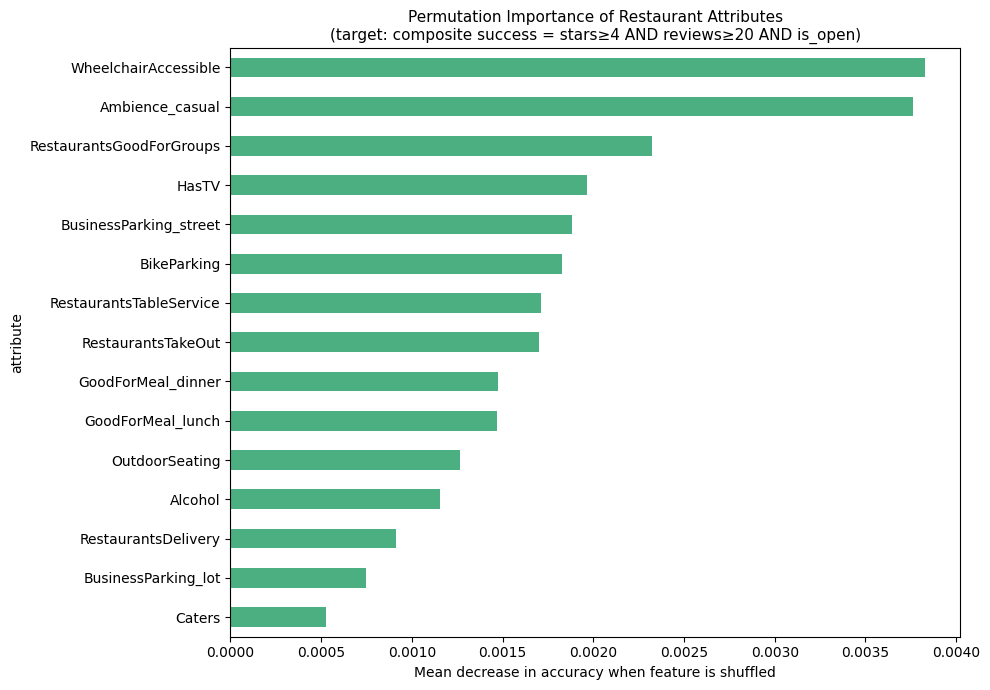

In [43]:
# Plotting Bar Chart
fig, ax = plt.subplots(figsize=(10, 7))
importance_df.head(15).sort_values('importance').plot(
    kind='barh', x='attribute', y='importance', legend=False, ax=ax, color='#4caf82'
)
ax.set_title(
    "Permutation Importance of Restaurant Attributes\n"
    "(target: composite success = stars≥4 AND reviews≥20 AND is_open)",
    fontsize=11
)
ax.set_xlabel("Mean decrease in accuracy when feature is shuffled")
plt.tight_layout()
plt.show()


## 5.3 Aggregate Review & Tip Data

In [44]:
# function for classifying text review sentiment 
def stars_to_sentiment(stars):
    if stars >= 4:   return 'positive'
    elif stars == 3: return 'neutral'
    else:            return 'negative'

review['sentiment'] = review['stars'].apply(stars_to_sentiment)
print("Review sentiment distribution:")
print(review['sentiment'].value_counts().to_string())

# aggregating by business
review_agg = review.groupby('business_id').agg(
    avg_stars_review = ('stars',     'mean'),
    total_reviews    = ('stars',     'count'),
    positive_count   = ('sentiment', lambda x: (x == 'positive').sum()),
    neutral_count    = ('sentiment', lambda x: (x == 'neutral').sum()),
    negative_count   = ('sentiment', lambda x: (x == 'negative').sum()),
).reset_index()

print(f"\nReview agg shape : {review_agg.shape}")

Review sentiment distribution:
sentiment
positive    4684545
negative    1613801
neutral      691934

Review agg shape : (150346, 6)


## 11. Final Merge & Save


In [48]:
# standardization
restaurant_businesses['city'] = restaurant_businesses['city'].str.strip().str.lower()
restaurant_businesses['postal_code'] = restaurant_businesses['postal_code'].str.strip().str.lower()
restaurant_businesses['categories'] = restaurant_businesses['categories'].str.strip().str.lower()
restaurant_businesses['attributes'] = (
    restaurant_businesses['attributes'].astype(str).str.strip().str.lower()
)

# merge with other dataset
df = restaurant_businesses.copy()
df = df.merge(review_agg, on='business_id', how='left')

# Drop temporary helper columns (not needed in the output CSV)
df.drop(columns=['attrs_parsed', 'attrs_flat'], inplace=True)

print(f"Final restaurant_merged shape : {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample (first 2 rows, selected columns):")
print(df[['business_id', 'name', 'stars', 'is_open',
          'days_open', 'avg_daily_hours',
          'top10_attr_count', 'attr_weighted_score',
          'total_reviews']].head(2).to_string())


Final restaurant_merged shape : (136602, 23)

Columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours', 'days_open', 'avg_daily_hours', 'top10_attr_count', 'attr_weighted_score', 'avg_stars_review', 'total_reviews', 'positive_count', 'neutral_count', 'negative_count']

Sample (first 2 rows, selected columns):
              business_id                      name  stars  is_open  days_open  avg_daily_hours  top10_attr_count  attr_weighted_score  total_reviews
0  Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ    5.0      NaN          7              8.0                 0                  0.0              7
1  mpf3x-BjTdTEA3yCZrAYPw             The UPS Store    3.0      NaN          6              8.0                 0                  0.0             15


In [49]:
# save all
os.makedirs('output', exist_ok=True)
df.to_csv('output/restaurant_merged.csv', index=False)

print(f"Saved output/restaurant_merged.csv  ->  {df.shape}")
print()
print(f"Both features available for all {len(df):,} restaurants (labeled + unlabeled).")


Saved output/restaurant_merged.csv  ->  (136602, 23)

Both features available for all 136,602 restaurants (labeled + unlabeled).
